# 04 - Data Visualization

Notebook ini menyajikan visualisasi dari hasil **Exploratory Data Analysis** agar pola pada dataset IMDb lebih mudah dipahami.

**Visualisasi yang dibuat:**

1. Distribusi rating dan pendapatan.
2. Pemeriksaan outlier pendapatan.
3. Jumlah film dan rata-rata rating per tahun.
4. Genre terbanyak dan rata-rata rating per genre.
5. Sutradara dengan film terbanyak.
6. Hubungan antar variabel (scatter plot dan heatmap korelasi).

## 1. Import Library & Pengaturan Tema

In [1]:
# Mengimpor library yang dibutuhkan untuk visualisasi
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema dasar seluruh grafik
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

## 2. Load Dataset Bersih

In [2]:
# Membaca dataset hasil cleaning
df = pd.read_csv("../data/imdb_movie_dataset_clean.csv")

print("Ukuran data:", df.shape)
df.head(3)

Ukuran data: (1000, 11)


,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,264.275,76.0
1,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.460,65.0
2,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.120,62.0


## 3. Distribusi Rating Film

Histogram untuk melihat sebaran rating dan bentuk distribusinya.

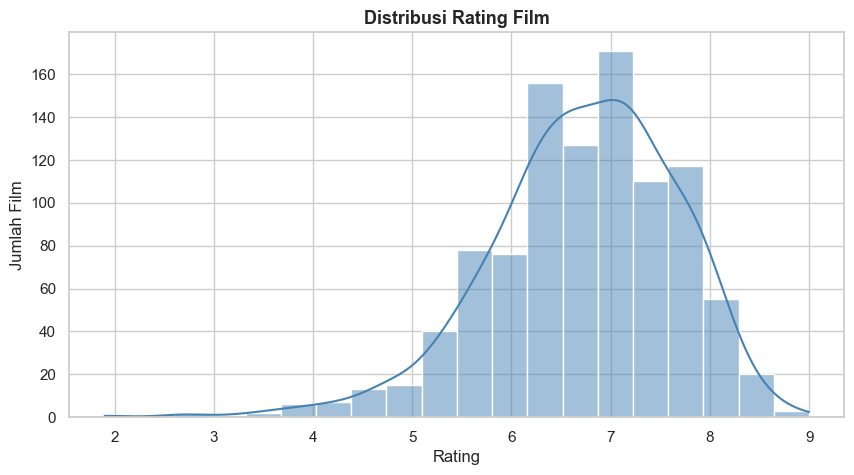

In [3]:
# Histogram distribusi rating
plt.figure(figsize=(10, 5))
sns.histplot(df["Rating"], bins=20, kde=True, color="steelblue")
plt.title("Distribusi Rating Film")
plt.xlabel("Rating")
plt.ylabel("Jumlah Film")
plt.show()

## 4. Distribusi Pendapatan Film

Histogram pendapatan setelah outlier dipotong pada tahap cleaning.

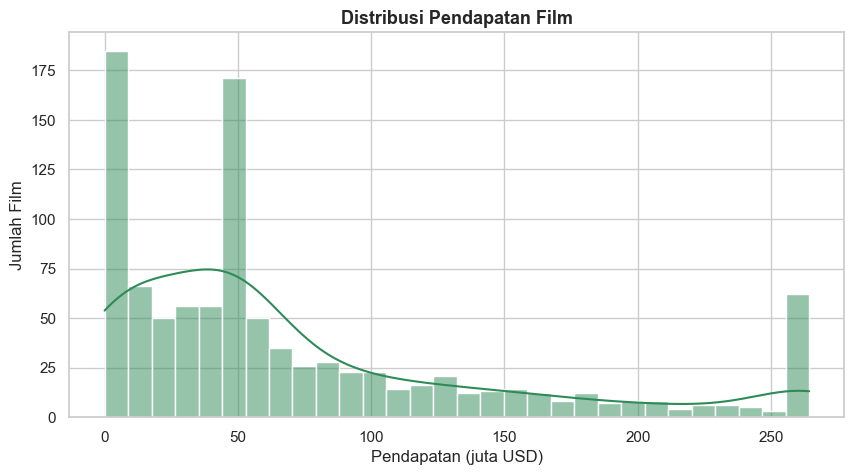

In [4]:
# Histogram distribusi pendapatan
plt.figure(figsize=(10, 5))
sns.histplot(df["Revenue (Millions)"], bins=30, kde=True, color="seagreen")
plt.title("Distribusi Pendapatan Film")
plt.xlabel("Pendapatan (juta USD)")
plt.ylabel("Jumlah Film")
plt.show()

## 5. Pemeriksaan Outlier Pendapatan

Boxplot memperlihatkan sebaran, median, dan sisa nilai ekstrem pada pendapatan film.

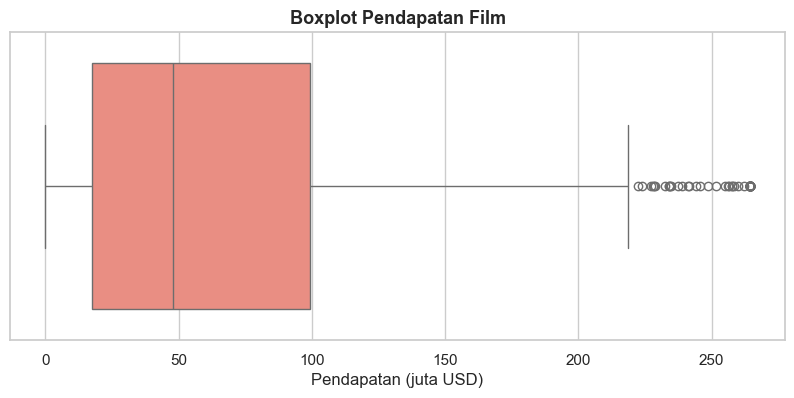

In [5]:
# Boxplot pendapatan untuk melihat sebaran dan outlier
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Revenue (Millions)"], color="salmon")
plt.title("Boxplot Pendapatan Film")
plt.xlabel("Pendapatan (juta USD)")
plt.show()

## 6. Jumlah Film per Tahun

Melihat banyaknya film yang masuk dataset setiap tahun.

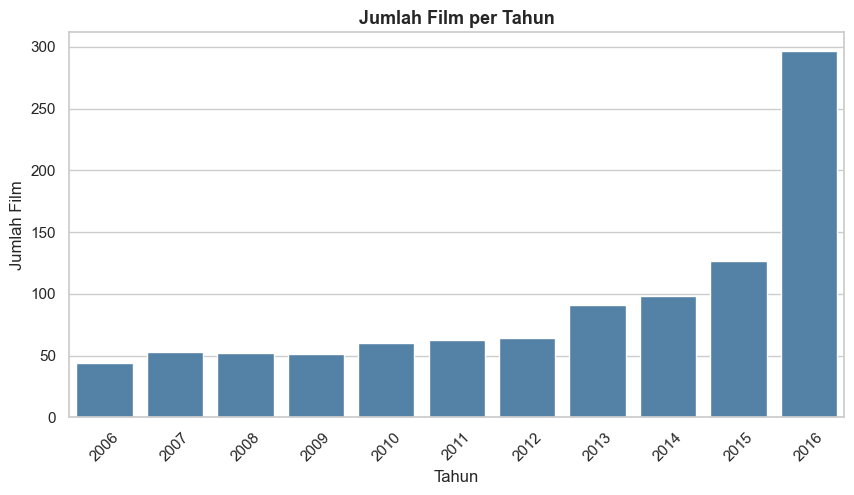

In [6]:
# Bar chart jumlah film per tahun
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Year", color="steelblue")
plt.title("Jumlah Film per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Film")
plt.xticks(rotation=45)
plt.show()

## 7. Tren Rata-rata Rating per Tahun

Memantau apakah kualitas film (menurut rating) berubah dari tahun ke tahun.

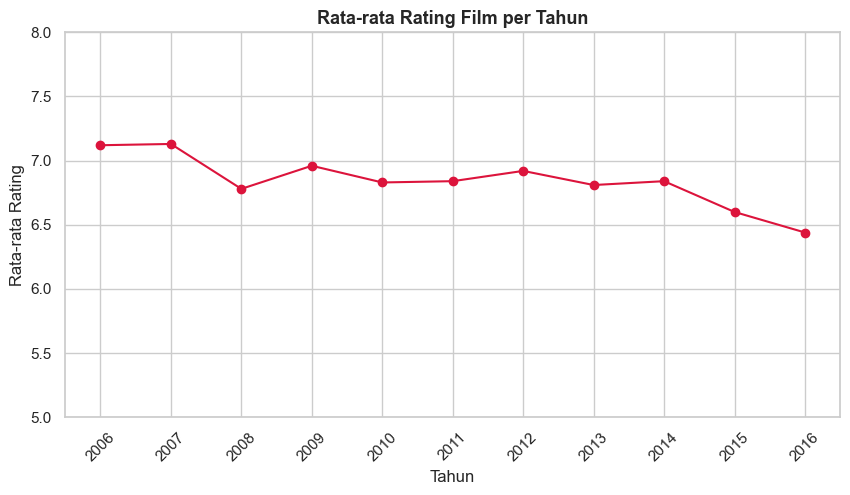

In [7]:
# Menghitung rata-rata rating per tahun
rating_tahunan = df.groupby("Year")["Rating"].mean().round(2)

# Line chart tren rating
plt.figure(figsize=(10, 5))
plt.plot(rating_tahunan.index, rating_tahunan.values, marker="o", color="crimson")
plt.title("Rata-rata Rating Film per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Rating")
plt.xticks(rating_tahunan.index, rotation=45)
plt.ylim(5, 8)
plt.show()

## 8. Genre dengan Jumlah Film Terbanyak

Genre dipecah lebih dulu karena satu film dapat memiliki beberapa genre.

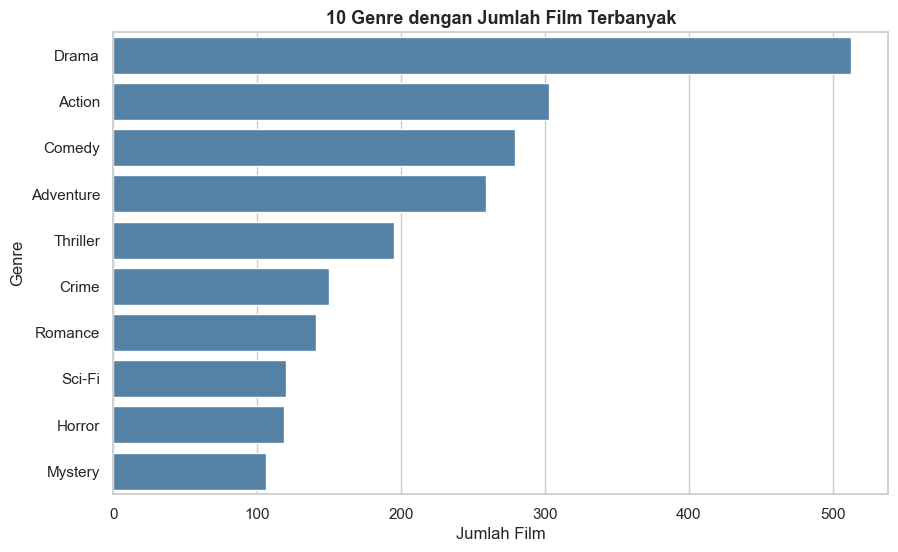

In [8]:
# Memecah kolom Genre menjadi satu genre per baris
genre_df = df.assign(Genre=df["Genre"].str.split(",")).explode("Genre")
genre_df["Genre"] = genre_df["Genre"].str.strip()

# Mengambil 10 genre terbanyak
top_10_genre = genre_df["Genre"].value_counts().head(10)

# Horizontal bar chart jumlah film per genre
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_genre.values, y=top_10_genre.index, color="steelblue")
plt.title("10 Genre dengan Jumlah Film Terbanyak")
plt.xlabel("Jumlah Film")
plt.ylabel("Genre")
plt.show()

## 9. Rata-rata Rating pada 10 Genre Terbanyak

Membandingkan kualitas film antar genre yang paling banyak diproduksi.

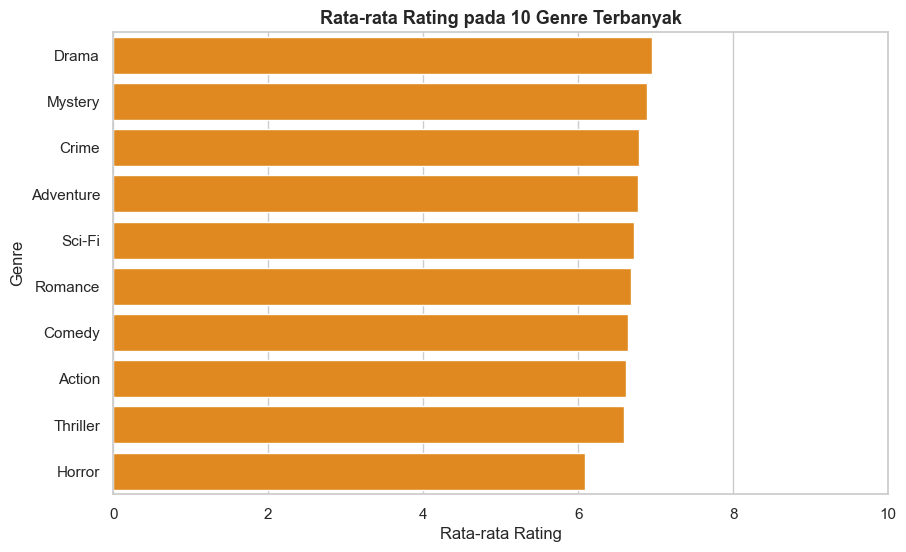

In [9]:
# Menghitung rata-rata rating pada 10 genre terbanyak
rata_rating_genre = (
    genre_df[genre_df["Genre"].isin(top_10_genre.index)]
    .groupby("Genre")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

# Horizontal bar chart rata-rata rating per genre
plt.figure(figsize=(10, 6))
sns.barplot(x=rata_rating_genre.values, y=rata_rating_genre.index, color="darkorange")
plt.title("Rata-rata Rating pada 10 Genre Terbanyak")
plt.xlabel("Rata-rata Rating")
plt.ylabel("Genre")
plt.xlim(0, 10)
plt.show()

## 10. Rata-rata Pendapatan per Genre

Genre mana yang secara rata-rata menghasilkan pendapatan tertinggi.

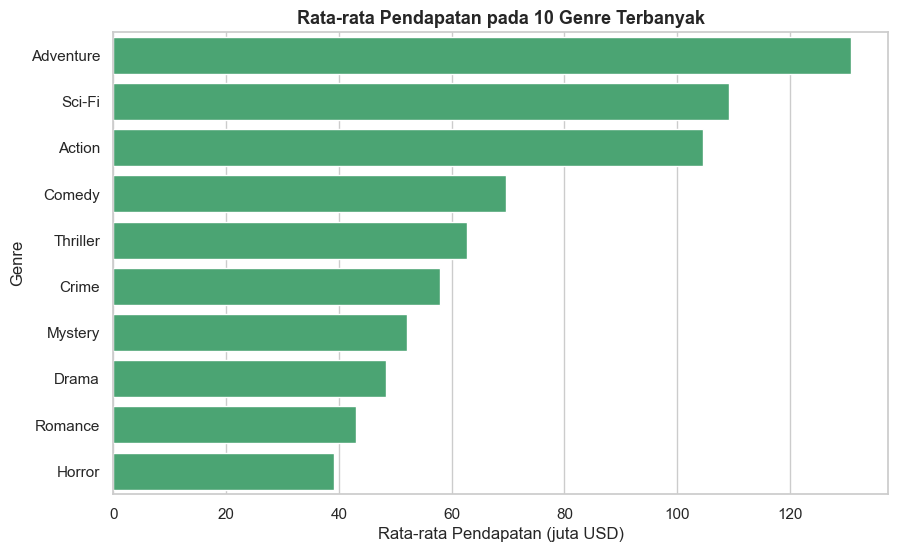

In [10]:
# Menghitung rata-rata pendapatan pada 10 genre terbanyak
rata_revenue_genre = (
    genre_df[genre_df["Genre"].isin(top_10_genre.index)]
    .groupby("Genre")["Revenue (Millions)"]
    .mean()
    .sort_values(ascending=False)
)

# Horizontal bar chart rata-rata pendapatan per genre
plt.figure(figsize=(10, 6))
sns.barplot(x=rata_revenue_genre.values, y=rata_revenue_genre.index, color="mediumseagreen")
plt.title("Rata-rata Pendapatan pada 10 Genre Terbanyak")
plt.xlabel("Rata-rata Pendapatan (juta USD)")
plt.ylabel("Genre")
plt.show()

## 11. Sutradara dengan Film Terbanyak

10 sutradara yang paling banyak mengarahkan film pada dataset ini.

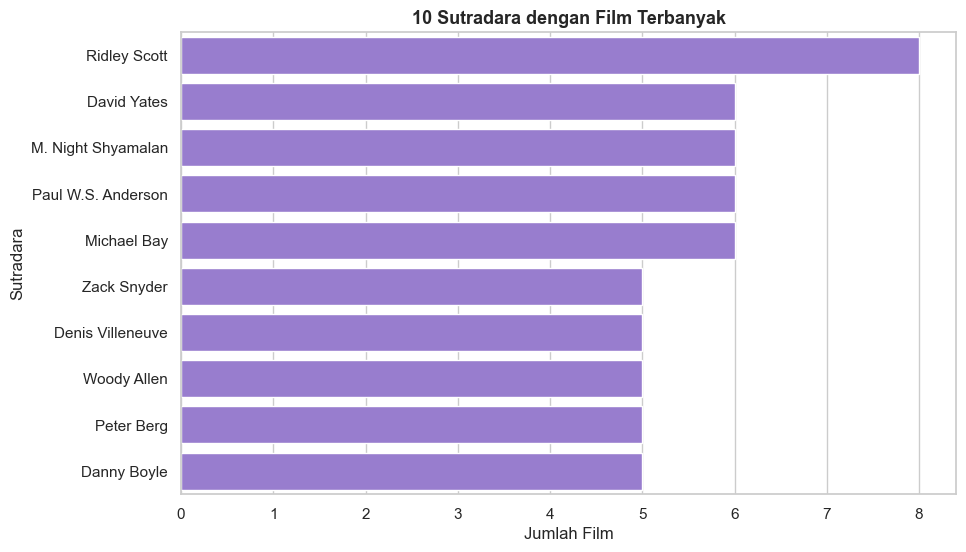

In [11]:
# Mengambil 10 sutradara dengan film terbanyak
top_10_director = df["Director"].value_counts().head(10)

# Horizontal bar chart sutradara
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_director.values, y=top_10_director.index, color="mediumpurple")
plt.title("10 Sutradara dengan Film Terbanyak")
plt.xlabel("Jumlah Film")
plt.ylabel("Sutradara")
plt.show()

## 12. Hubungan Rating dan Metascore

Scatter plot untuk melihat seberapa sejalan penilaian penonton (rating) dan kritikus (metascore).

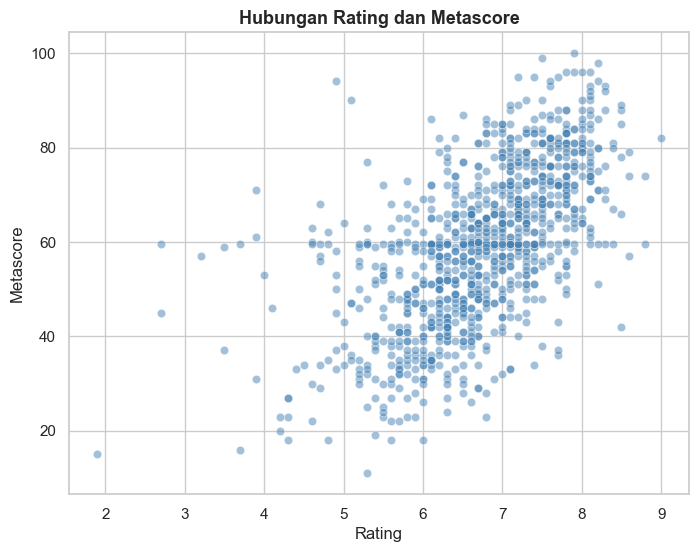

In [12]:
# Scatter plot rating vs metascore
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Rating", y="Metascore", alpha=0.5, color="steelblue")
plt.title("Hubungan Rating dan Metascore")
plt.xlabel("Rating")
plt.ylabel("Metascore")
plt.show()

## 13. Hubungan Popularitas dan Pendapatan

Scatter plot jumlah votes terhadap pendapatan; skala sumbu X dibuat logaritmik karena sebaran votes sangat lebar.

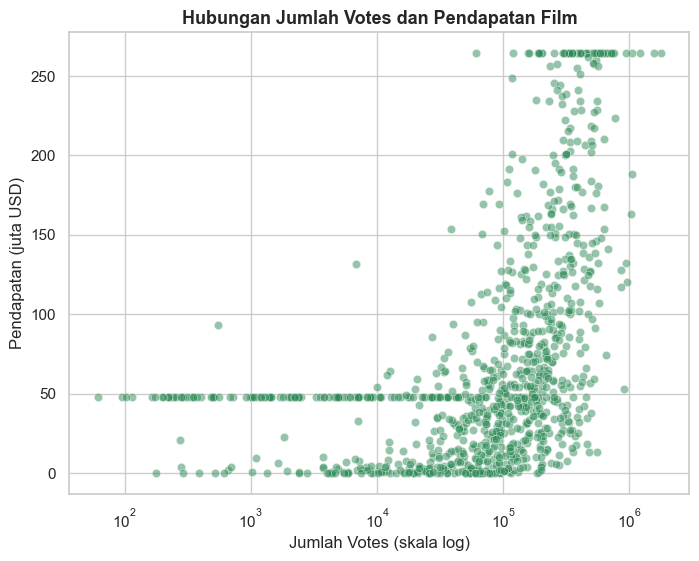

In [13]:
# Scatter plot votes vs pendapatan dengan skala log pada sumbu X
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Votes", y="Revenue (Millions)", alpha=0.5, color="seagreen")
plt.xscale("log")
plt.title("Hubungan Jumlah Votes dan Pendapatan Film")
plt.xlabel("Jumlah Votes (skala log)")
plt.ylabel("Pendapatan (juta USD)")
plt.show()

## 14. Heatmap Korelasi

Visualisasi matriks korelasi antar variabel numerik; warna merah menandakan hubungan positif yang kuat.

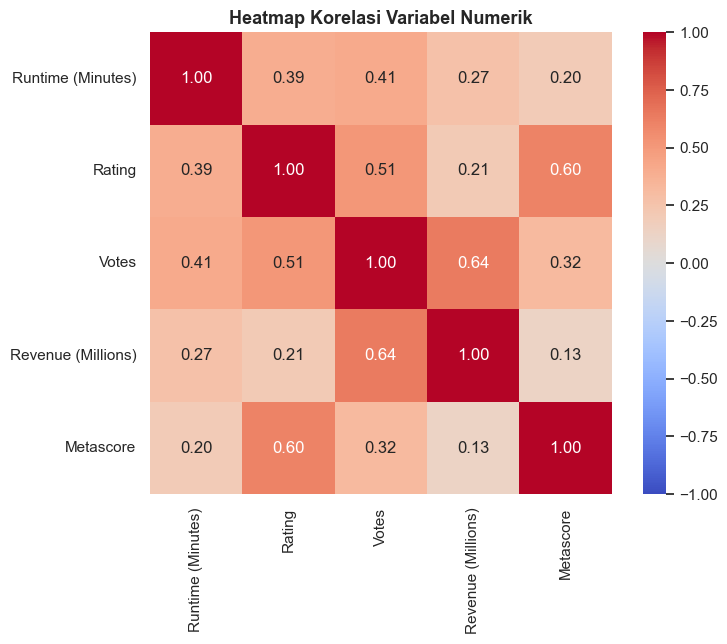

In [14]:
# Menghitung korelasi variabel numerik
kolom_numerik = ["Runtime (Minutes)", "Rating", "Votes", "Revenue (Millions)", "Metascore"]
korelasi = df[kolom_numerik].corr()

# Heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Heatmap Korelasi Variabel Numerik")
plt.show()

## 15. Kesimpulan Visualisasi

**Temuan utama dari grafik:**

- **Rating** berdistribusi mendekati normal dengan puncak di sekitar 6-7; hanya sedikit film yang berating di bawah 4 atau di atas 8.
- **Pendapatan** berdistribusi miring ke kanan (right-skewed); sebagian besar film berpendapatan di bawah 100 juta dan hanya sedikit yang sangat besar, bahkan setelah outlier dipotong.
- **Jumlah film** terus meningkat setiap tahun dan melonjak pada 2015-2016.
- Sebaliknya, **rata-rata rating per tahun menurun** dari 7,12 (2006) menjadi 6,44 (2016).
- **Drama, Action, dan Comedy** mendominasi jumlah film, sedangkan **Biography dan Drama** memiliki rata-rata rating tertinggi.
- **Animation dan Adventure** mencatat rata-rata pendapatan tertinggi.
- **Ridley Scott** adalah sutradara dengan film terbanyak (8 film).
- Scatter plot dan heatmap menunjukkan bahwa **jumlah votes adalah variabel yang paling berhubungan dengan pendapatan (0,64)**, sedangkan rating hanya berhubungan lemah dengan pendapatan (0,21).
- **Rating dan Metascore** memiliki hubungan positif cukup kuat (0,60): penilaian penonton dan kritikus cenderung searah.